## Imports e configuração

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import json
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.measure import regionprops

%matplotlib inline

BASE_DIR      = Path("..")
PATH_PROCESSED = BASE_DIR / "data" / "processed" 
PATH_IMAGES   = BASE_DIR / "data" / "raw" / "BBBC020_v1_images"
PATH_GT_CELLS = BASE_DIR / "data" / "processed" / "01_ground_truth" / "gt_cells"

# Carregar manifesto de imagens com ground truth e métricas de filtragem
with open(BASE_DIR / "data" / "metadata" / "ground_truth_manifest.json") as f:
    MANIFEST = json.load(f)

df_filt = pd.read_csv(BASE_DIR / "data" / "metadata" / "metricas_filtragem.csv")
MELHOR_FILTRO = {}
for _, row in df_filt.iterrows():
    if row["melhor_filtro"]:
        MELHOR_FILTRO[row["imagem"]] = row["filtro"]


# ── Pré-processamento ──────────────────────────────────────────────────────────
def _carregar_c1(img_id):
    for f in (PATH_IMAGES / img_id).glob("*_c1.TIF"):
        return cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
    return None

def _clahe(img):
    return cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img)

def _fft_lp(img, raio=50):
    f = np.fft.fft2(img.astype(np.float64))
    fshift = np.fft.fftshift(f)
    H, W = img.shape
    Y, X = np.ogrid[:H, :W]
    mask = ((X - W // 2) ** 2 + (Y - H // 2) ** 2) <= raio ** 2
    result = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift * mask)))
    return np.clip(result, 0, 255).astype(np.uint8)


# ── Detecção de bordas ─────────────────────────────────────────────────────────
def _sobel(img):
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx ** 2 + sy ** 2)
    return cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def _laplaciano(img):
    lap = np.abs(cv2.Laplacian(img, cv2.CV_64F))
    return cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


# ── Segmentação ────────────────────────────────────────────────────────────────
def _watershed(img, min_distance=15, fuse_thresh=0.5, sigma_mask=20):
    from scipy import ndimage as ndi
    from skimage.feature import peak_local_max
    from skimage.measure import regionprops

    # ── Diagnóstico (descomente se quiser checar se fill está funcionando) ──
    # _b = cv2.GaussianBlur(img,(0,0),sigmaX=sigma_mask)
    # _, _bm = cv2.threshold(_b,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    # _bf = ndi.binary_fill_holes(_bm).astype(np.uint8)
    # print(f"foreground antes fill: {_bm.mean()*100:.1f}%  após: {_bf.mean()*100:.1f}%")
    # ────────────────────────────────────────────────────────────────────────

    # 1. Máscara: sigma grande preenche interior escuro das células
    img_blur = cv2.GaussianBlur(img, (0, 0), sigmaX=sigma_mask)
    _, binary = cv2.threshold(img_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = ndi.binary_fill_holes(binary.astype(bool)).astype(np.uint8) * 255
    k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k3)

    # 2. Gradiente do original — usado como relevo E na fusão (calculado uma vez)
    img_g = cv2.GaussianBlur(img, (0, 0), sigmaX=1.5)
    gx = cv2.Sobel(img_g, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img_g, cv2.CV_64F, 0, 1, ksize=3)
    gradient = cv2.normalize(
        np.sqrt(gx**2 + gy**2), None, 0, 255, cv2.NORM_MINMAX
    ).astype(np.uint8)

    # 3. Distância transform da máscara preenchida → picos no centro de cada célula
    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    dist_smooth = cv2.GaussianBlur(dist, (0, 0), sigmaX=5)

    # 4. Sementes: um pico por célula
    coords = peak_local_max(dist_smooth, min_distance=min_distance, threshold_rel=0.1)
    local_max = np.zeros(dist.shape, dtype=bool)
    if len(coords):
        local_max[coords[:, 0], coords[:, 1]] = True
    local_max &= binary.astype(bool)
    seed_labels, _ = ndi.label(local_max)

    # 5. Marcadores
    markers = np.zeros(img.shape, dtype=np.int32)
    markers[seed_labels > 0] = seed_labels[seed_labels > 0] + 1
    markers[binary == 0] = 1   # fora da máscara = fundo

    # 6. Watershed: relevo = gradiente (membrana brilhante = barreira natural)
    relief = cv2.merge([gradient, gradient, gradient])
    markers = cv2.watershed(relief, markers)

    # 7. Fusão de fragmentos com borda fraca
    labels = markers.copy().astype(np.int32)
    labels[(labels <= 1) | (labels == -1)] = 0
    strong_edge = gradient > int(fuse_thresh * 255)

    for region in sorted(regionprops(labels), key=lambda r: r.area, reverse=True):
        lbl = region.label
        if lbl <= 1:
            continue
        dil = cv2.dilate((labels == lbl).astype(np.uint8), np.ones((3, 3), np.uint8))
        for adj in np.unique(labels[dil > 0]):
            if adj <= 1 or adj == lbl:
                continue
            border = (dil > 0) & (labels == adj)
            if border.any() and strong_edge[border].mean() < 0.3:
                labels[labels == adj] = lbl

    # 8. Filtro área + re-rotulação
    unique_lbls = [u for u in np.unique(labels) if u > 1]
    if unique_lbls:
        areas    = np.array([np.sum(labels == u) for u in unique_lbls])
        min_area = max(300, np.median(areas) / 4)
        valid    = [u for u, a in zip(unique_lbls, areas) if a >= min_area]
    else:
        valid = []

    new_labels = np.ones_like(labels, dtype=np.int32)
    for i, u in enumerate(valid, start=2):
        new_labels[labels == u] = i
    new_labels[markers == -1] = -1

    return new_labels, len(valid)

def _colorir_watershed(markers):
    rng = np.random.default_rng(42)
    vis = np.zeros((*markers.shape, 3), dtype=np.uint8)
    for label in np.unique(markers):
        if label <= 1:
            continue
        vis[markers == label] = rng.integers(60, 240, 3)
    vis[markers == -1] = [220, 50, 50]   # bordas em vermelho
    return vis


# ── Ground Truth ───────────────────────────────────────────────────────────────
def _gt_count(img_id):
    p = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    return int(np.load(str(p)).max()) if p.exists() else None

def _gt_binary(img_id):
    p = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    return (np.load(str(p)) > 0).astype(np.uint8) if p.exists() else None

def _cell_level_metrics(pred_labels, gt_labels, iou_thresh=0.5):
    """
    Calcula TP, FP, FN comparando máscaras rotuladas de células individuais.
    pred_labels: array com labels (fundo=1, células>1, borda=-1)
    gt_labels:   array com labels (fundo=0, células>0)
    """
    pred_cells = [l for l in np.unique(pred_labels) if l > 1]
    gt_cells   = [l for l in np.unique(gt_labels) if l > 0]
    matched_gt = set()
    tp = 0
    fp = 0
    for p in pred_cells:
        mask_p = (pred_labels == p)
        best_iou = 0
        best_gt = None
        for g in gt_cells:
            if g in matched_gt:
                continue
            mask_g = (gt_labels == g)
            inter = np.logical_and(mask_p, mask_g).sum()
            union = np.logical_or(mask_p, mask_g).sum()
            iou = inter / union if union > 0 else 0
            if iou > best_iou:
                best_iou = iou
                best_gt = g
        if best_iou > iou_thresh and best_gt is not None:
            tp += 1
            matched_gt.add(best_gt)
        else:
            fp += 1
    fn = len(gt_cells) - len(matched_gt)
    return tp, fp, fn


# ── Carregamento ───────────────────────────────────────────────────────────────
dict_imgs  = {p.name: _carregar_c1(p.name) for p in sorted(PATH_IMAGES.iterdir()) if p.is_dir()}
dict_imgs  = {k: v for k, v in dict_imgs.items() if v is not None}
ids_com_gt = [k for k in dict_imgs if _gt_count(k) is not None]

ID_EX  = ids_com_gt[0]
IMG_EX = dict_imgs[ID_EX]
print(f"{len(dict_imgs)} imagens | {len(ids_com_gt)} com GT | exemplo: '{ID_EX}'")
print(f"shape={IMG_EX.shape} | GT células={_gt_count(ID_EX)}")

25 imagens | 20 com GT | exemplo: 'jw-15min 1'
shape=(1040, 1388) | GT células=29


## 2. Detecção de Bordas — Sobel vs Laplaciano

Visualização comparativa; na segmentação real (Seção 3) usamos a transformada de distância porque os operadores de borda identificam apenas a periferia das células, enquanto o mapa de distância isola o centro de cada uma — essencial para o Watershed separar células adjacentes.

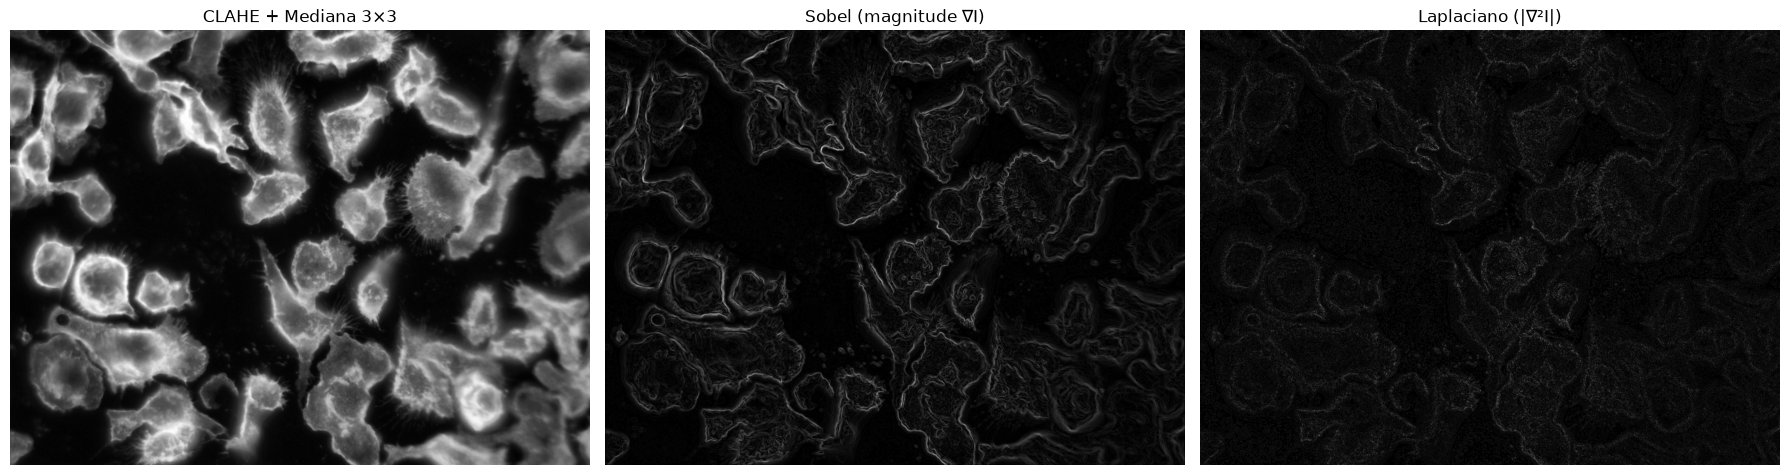

In [16]:
img_proc = _clahe(cv2.medianBlur(IMG_EX, 3))

sobel_ex = _sobel(img_proc)
lap_ex   = _laplaciano(img_proc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (img, cmap, t) in zip(axes, [
    (img_proc, 'gray', "CLAHE + Mediana 3×3"),
    (sobel_ex, 'gray', "Sobel (magnitude ∇I)"),
    (lap_ex,   'gray', "Laplaciano (|∇²I|)"),
]):
    ax.imshow(img, cmap=cmap); ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.show()

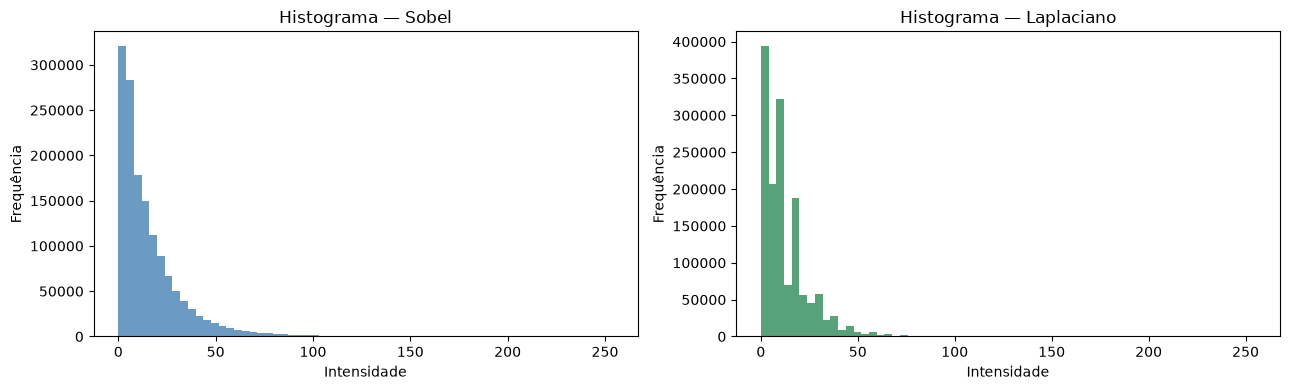

In [17]:
# Análise quantitativa dos mapas de borda
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (img, t, cor) in zip(axes, [
    (sobel_ex, "Sobel",      'steelblue'),
    (lap_ex,   "Laplaciano", 'seagreen'),
]):
    ax.hist(img.ravel(), bins=64, color=cor, alpha=0.8, edgecolor='none')
    ax.set_title(f"Histograma — {t}")
    ax.set_xlabel("Intensidade")
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

## 3. Segmentação via Watershed — Etapas Intermediárias

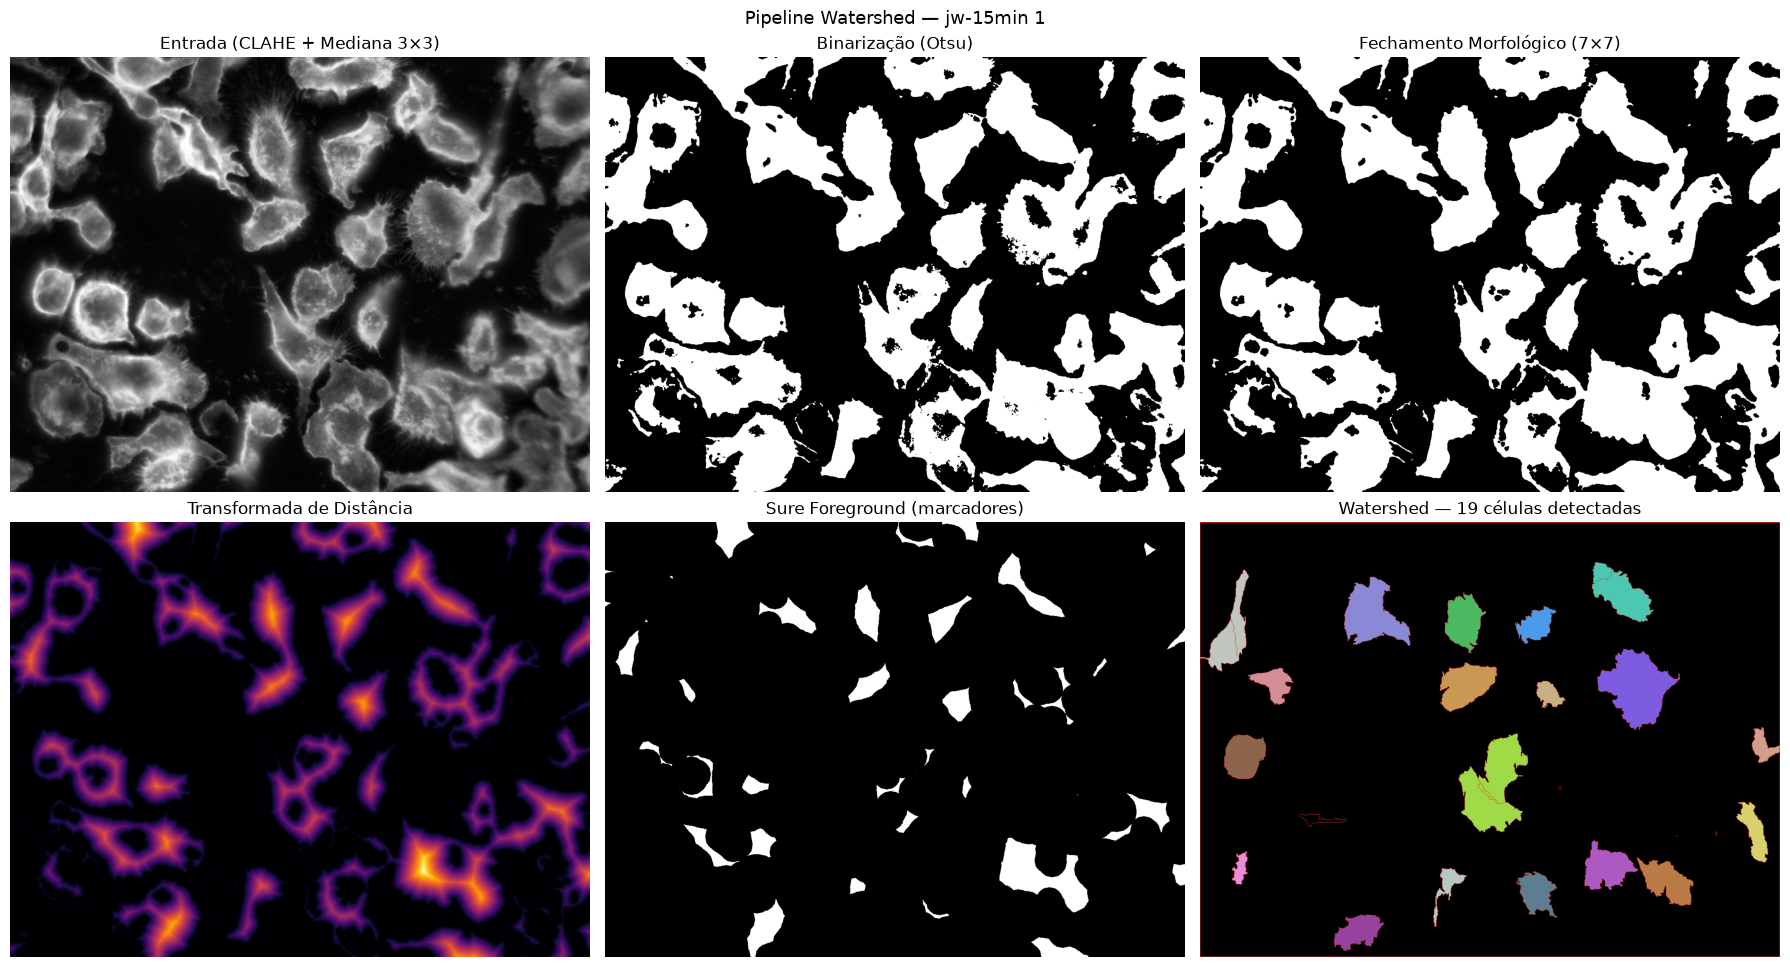

In [18]:
# Reusa img_proc da seção anterior
_, binary_otsu = cv2.threshold(img_proc, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
k              = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
binary_closed  = cv2.morphologyEx(binary_otsu, cv2.MORPH_CLOSE, k)
sure_bg        = cv2.dilate(binary_closed, k, iterations=3)
dist           = cv2.distanceTransform(binary_closed, cv2.DIST_L2, 5)
_, sure_fg_raw = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
sure_fg        = sure_fg_raw.astype(np.uint8)

markers_ex, n_ex = _watershed(img_proc)
vis_ex           = _colorir_watershed(markers_ex)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (img, cmap, t) in zip(axes.ravel(), [
    (img_proc,      'gray',    "Entrada (CLAHE + Mediana 3×3)"),
    (binary_otsu,   'gray',    "Binarização (Otsu)"),
    (binary_closed, 'gray',    "Fechamento Morfológico (7×7)"),
    (dist,          'inferno', "Transformada de Distância"),
    (sure_fg,       'gray',    "Sure Foreground (marcadores)"),
    (vis_ex,        None,      f"Watershed — {n_ex} células detectadas"),
]):
    ax.imshow(img, cmap=cmap); ax.set_title(t); ax.axis('off')

plt.suptitle(f"Pipeline Watershed — {ID_EX}", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Contagem e Validação

In [19]:
gt_n   = _gt_count(ID_EX)
gt_bin = _gt_binary(ID_EX)
pred_bin = (markers_ex > 1).astype(np.uint8)

inter = np.logical_and(pred_bin, gt_bin).sum()
union = np.logical_or(pred_bin, gt_bin).sum()
iou   = inter / union if union > 0 else 0.0

erro_abs  = abs(n_ex - gt_n)
erro_perc = erro_abs / gt_n * 100 if gt_n > 0 else float('nan')

print(f"=== Validação — {ID_EX} ===")
print(f"Detectadas  : {n_ex}")
print(f"Gabarito    : {gt_n}")
print(f"Erro abs.   : {erro_abs}")
print(f"Erro rel.   : {erro_perc:.1f}%")
print(f"IoU binária : {iou:.4f}")

=== Validação — jw-15min 1 ===
Detectadas  : 19
Gabarito    : 29
Erro abs.   : 10
Erro rel.   : 34.5%
IoU binária : 0.2663


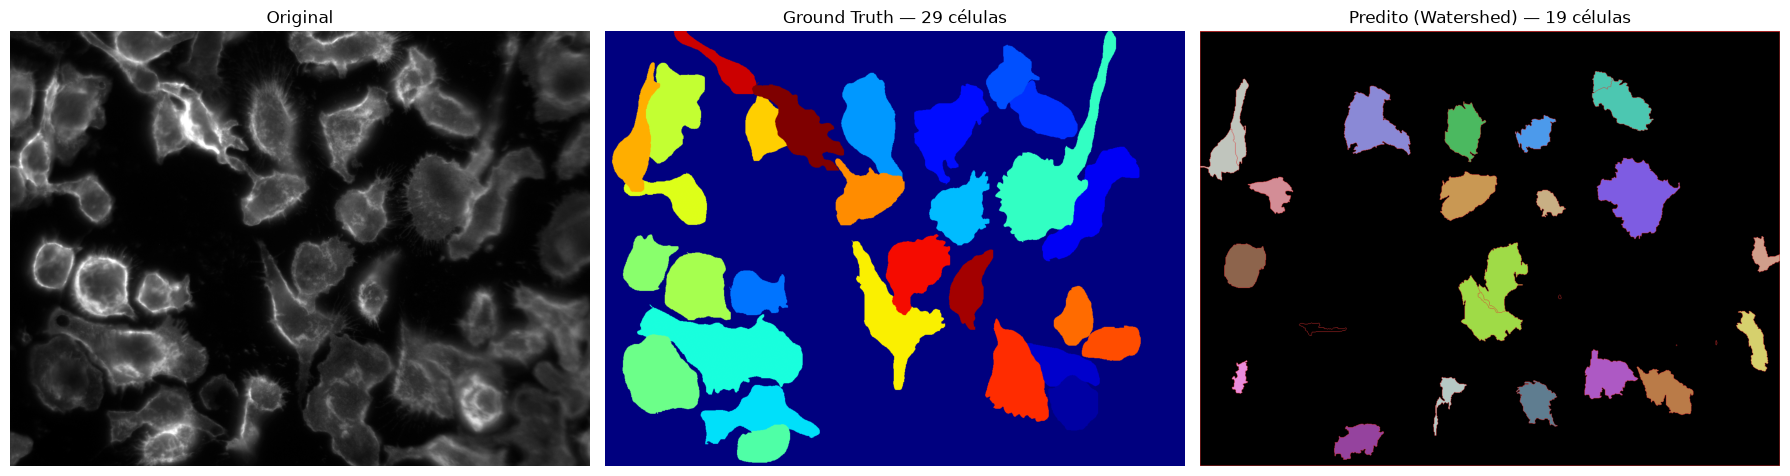

In [20]:
gt_labeled = np.load(str(PATH_GT_CELLS / f"{ID_EX}_gt_cells.npy"))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (img, cmap, t) in zip(axes, [
    (IMG_EX,    'gray', "Original"),
    (gt_labeled, 'jet', f"Ground Truth — {gt_n} células"),
    (vis_ex,     None,  f"Predito (Watershed) — {n_ex} células"),
]):
    ax.imshow(img, cmap=cmap); ax.set_title(t); ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Análise Comparativa de Pipelines

In [ ]:
# Criar diretório de saída para as máscaras segmentadas
out_masks = PATH_PROCESSED / "03_segmented_masks"
out_masks.mkdir(parents=True, exist_ok=True)

registros_seg = []

for img_id in MANIFEST:
    # Determinar filtro a ser utilizado (melhor filtro segundo Notebook 02)
    filtro = MELHOR_FILTRO.get(img_id, "mediana")  # fallback mediana se não definido
    filt_img_path = PATH_PROCESSED / "02_filtered_images" / filtro / f"{img_id}.npy"
    if not filt_img_path.exists():
        print(f"Imagem filtrada não encontrada: {filt_img_path}")
        continue
    
    img_filt = np.load(str(filt_img_path))
    
    # Segmentação com Watershed (a função _watershed aplica Otsu internamente)
    markers, n_det = _watershed(img_filt)
    
    # Salvar máscara segmentada
    np.save(out_masks / f"{img_id}.npy", markers)
    
    # Carregar ground truth
    gt_path = PATH_GT_CELLS / f"{img_id}_gt_cells.npy"
    gt_labeled = np.load(str(gt_path))
    gt_n = int(gt_labeled.max())
    
    # Métricas de contagem
    erro_abs = abs(n_det - gt_n)
    erro_perc = erro_abs / gt_n * 100 if gt_n > 0 else np.nan
    
    # IoU binária
    pred_bin = (markers > 1).astype(np.uint8)
    gt_bin   = (gt_labeled > 0).astype(np.uint8)
    inter = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    iou   = inter / union if union > 0 else 0.0
    
    # Métricas por célula (TP, FP, FN)
    tp, fp, fn = _cell_level_metrics(markers, gt_labeled)
    
    registros_seg.append({
        "imagem": img_id,
        "contagem_detectada": n_det,
        "contagem_gabarito": gt_n,
        "erro_absoluto": erro_abs,
        "erro_percentual": round(erro_perc, 2),
        "iou": round(iou, 4),
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

# Salvar CSV de métricas de segmentação
df_seg = pd.DataFrame(registros_seg)
csv_seg_path = BASE_DIR / "data" / "metadata" / "metricas_segmentacao.csv"
df_seg.to_csv(csv_seg_path, index=False)
print(f"Métricas de segmentação salvas em {csv_seg_path}")
print(df_seg.head())

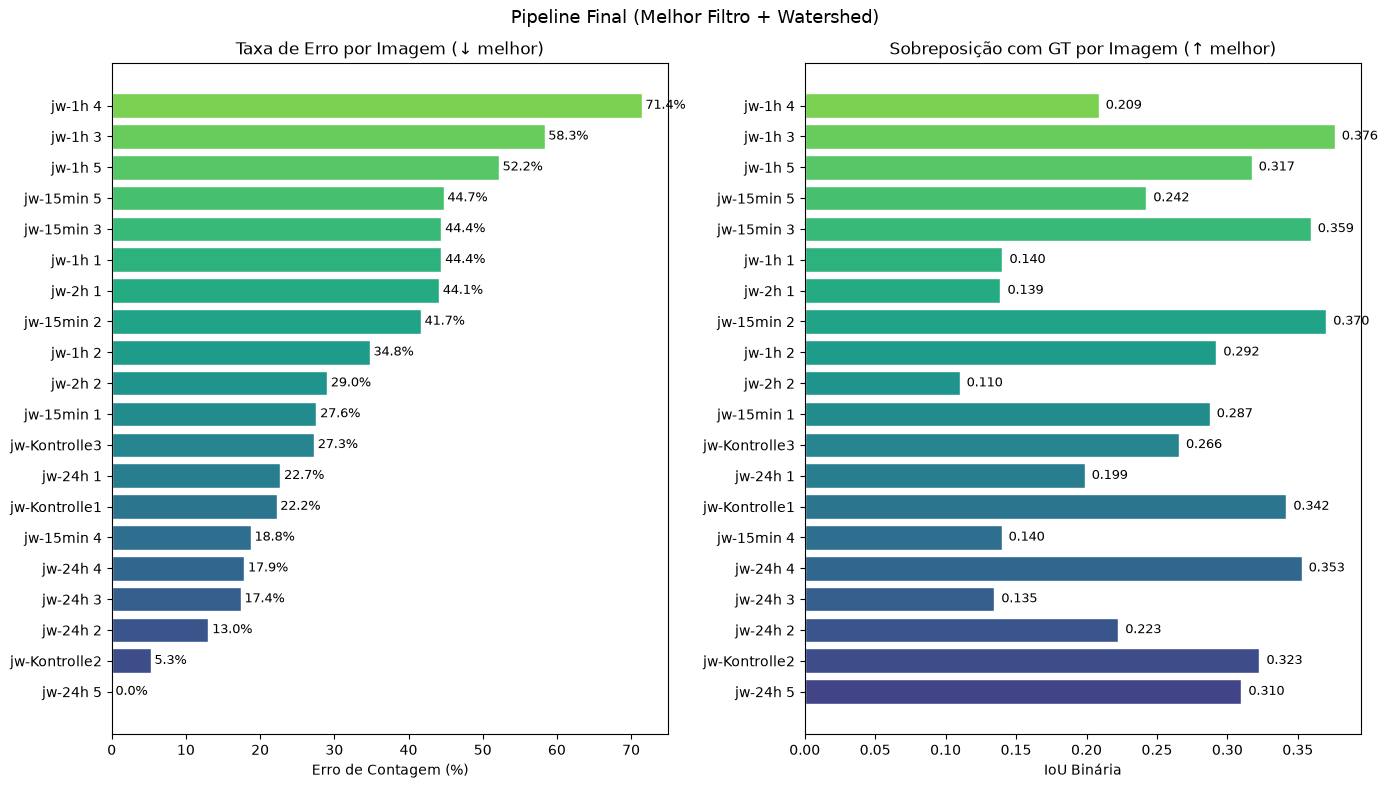

In [54]:
# Gráfico: Erro% e IoU por imagem (pipeline final)
df_sorted = df_seg.sort_values("erro_percentual")
cores = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_sorted)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5 + len(df_sorted)*0.15))

axes[0].barh(df_sorted["imagem"], df_sorted["erro_percentual"], color=cores, edgecolor='white')
axes[0].set_xlabel("Erro de Contagem (%)")
axes[0].set_title("Taxa de Erro por Imagem (↓ melhor)")
for i, v in enumerate(df_sorted["erro_percentual"]):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)

axes[1].barh(df_sorted["imagem"], df_sorted["iou"], color=cores, edgecolor='white')
axes[1].set_xlabel("IoU Binária")
axes[1].set_title("Sobreposição com GT por Imagem (↑ melhor)")
for i, v in enumerate(df_sorted["iou"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=9)

plt.suptitle("Pipeline Final (Melhor Filtro + Watershed)", fontsize=13)
plt.tight_layout()
plt.show()

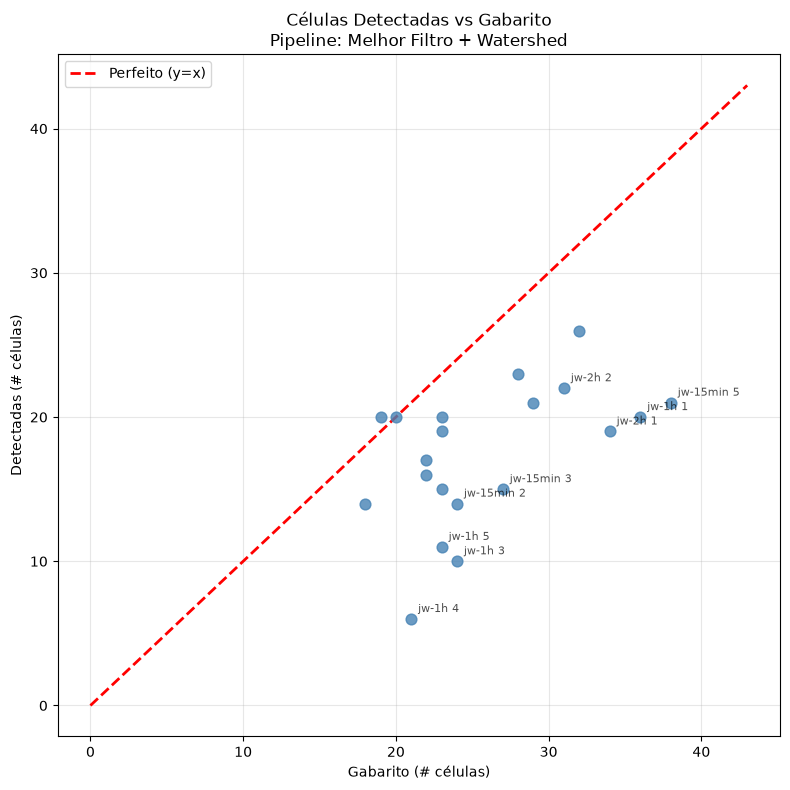

In [55]:
# Scatter: detectadas vs gabarito (pipeline final)
fig, ax = plt.subplots(figsize=(8, 8))

max_val = max(df_seg["contagem_gabarito"].max(), df_seg["contagem_detectada"].max()) + 5
ax.scatter(df_seg["contagem_gabarito"], df_seg["contagem_detectada"],
           alpha=0.8, color='steelblue', zorder=3, s=60)
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label="Perfeito (y=x)")

# Adicionar rótulos com nome da imagem nos pontos mais distantes
for _, row in df_seg.iterrows():
    erro = abs(row["contagem_detectada"] - row["contagem_gabarito"])
    if erro > df_seg["erro_absoluto"].mean():  # destaca acima da média de erro
        ax.annotate(row["imagem"], (row["contagem_gabarito"], row["contagem_detectada"]),
                    textcoords="offset points", xytext=(5,5), fontsize=8, alpha=0.7)

ax.set_xlabel("Gabarito (# células)")
ax.set_ylabel("Detectadas (# células)")
ax.set_title("Células Detectadas vs Gabarito\nPipeline: Melhor Filtro + Watershed", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
# Conclusão
print("=== Conclusão da Segmentação (Pipeline Final) ===")
print(f"Total de imagens processadas: {len(df_seg)}")
print(f"Erro absoluto médio   : {df_seg['erro_absoluto'].mean():.2f}")
print(f"Erro percentual médio : {df_seg['erro_percentual'].mean():.2f}%")
print(f"IoU médio             : {df_seg['iou'].mean():.4f}")
print(f"TP médio: {df_seg['tp'].mean():.1f} | FP médio: {df_seg['fp'].mean():.1f} | FN médio: {df_seg['fn'].mean():.1f}")

melhor_img = df_seg.loc[df_seg["erro_percentual"].idxmin()]
pior_img   = df_seg.loc[df_seg["erro_percentual"].idxmax()]

print(f"\nMelhor imagem: {melhor_img['imagem']} ({melhor_img['erro_percentual']:.1f}% erro, IoU={melhor_img['iou']:.3f})")
print(f"Pior imagem  : {pior_img['imagem']} ({pior_img['erro_percentual']:.1f}% erro, IoU={pior_img['iou']:.3f})")

=== Conclusão da Segmentação (Pipeline Final) ===
Total de imagens processadas: 20
Erro absoluto médio   : 8.50
Erro percentual médio : 31.86%
IoU médio             : 0.2565
TP médio: 0.1 | FP médio: 17.4 | FN médio: 25.7

Melhor imagem: jw-24h 5 (0.0% erro, IoU=0.310)
Pior imagem  : jw-1h 4 (71.4% erro, IoU=0.209)
